# Proposal Revision Classification (RQ3.1)

Replicates the API-documentation evolution methodology on the proposals
(`all_proposals.db`):

* **Step 1 — Identify revisions.** For each proposal we diff *consecutive*
  revisions, ordered by `revision_index` with a per-proposal direction chosen so
  `created_at` is monotonically increasing (some `created_at` are date-only and
  tie-prone, and some projects — Rust — store the index in reverse). Content
  changes come from diffing `ProposalRevision.content`; metadata changes
  (title / author / status) come from the structured tables.
* **Step 2 — Classify by heuristics.** Each change is labeled with a *part*
  (code / prose / metadata) and an *operation* (added / deleted / modified);
  modified prose is sub-typed (typo / formatting / rephrase / substantive).
* **Step 3 — Refine.** The sampling cell at the bottom prints random classified
  changes for manual inspection so the rules in `revision_analysis/classify.py`
  can be tuned.

This notebook answers:
* **RQ-3.1 — Which parts of proposals are frequently revised?**
* **Extra — How frequently are proposals changed?** (incl. in-progress vs terminal)

In [2]:
import sys
from pathlib import Path

# make the revision_analysis package importable from the notebooks/ dir
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from revision_analysis import pipeline, db

sns.set_theme(style="whitegrid")
PLOTS = Path("plots")
PLOTS.mkdir(exist_ok=True)
CACHE = Path("cache")
PROJECT_ID = None  # None = all 10 projects; set an int to focus on one

In [3]:
# Run the pipeline (or load cached parquet). Full corpus diff takes a few
# minutes; results are cached so re-running the analysis is instant.
def load_or_run(force=False):
    files = {n: CACHE / f"{n}.parquet" for n in
             ("content_changes", "metadata_changes", "revision_pairs")}
    if not force and all(f.exists() for f in files.values()):
        return {n: pd.read_parquet(f) for n, f in files.items()}
    return pipeline.run(project_id=PROJECT_ID, cache_dir=str(CACHE))


res = load_or_run(force=False)
content = res["content_changes"]
meta = res["metadata_changes"]
pairs = res["revision_pairs"]

with db.connect() as con:
    PROJ = db.project_names(con)
content["project"] = content["project_id"].map(PROJ)
meta["project"] = meta["project_id"].map(PROJ)
pairs["project"] = pairs["project_id"].map(PROJ)
len(content), len(meta), len(pairs)

(598742, 18817, 12642)

In [4]:
# Diagnostic: revision-ordering sanity check.
# Revisions are ordered by `revision_index` with a per-proposal direction chosen
# (db.direction_cte) so `created_at` is monotonically non-decreasing -- this
# handles date-only timestamp ties and projects whose index runs backwards (Rust).
# This cell flags any proposal whose `created_at` STILL decreases after the fix:
# a genuine anomaly (zig-zagging timestamps) that direction choice can't resolve.
anomalies = []
n_proposals = 0
with db.connect() as _con:
    for _revs in db.iter_proposal_revisions(_con):
        n_proposals += 1
        _ts = pd.to_datetime([r.created_at for r in _revs], errors="coerce", utc=True)
        _decs = int((_ts[1:] < _ts[:-1]).sum())
        if _decs:
            anomalies.append({
                "project": PROJ[_revs[0].project_id],
                "proposal_id": _revs[0].proposal_id,
                "n_decreasing_steps": _decs,
                "n_revisions": len(_revs),
            })
anom = pd.DataFrame(anomalies)
print(f"proposals with non-monotonic created_at after ordering fix: "
      f"{len(anom)} / {n_proposals}")
if not anom.empty:
    print(anom["project"].value_counts())
anom.sort_values("n_decreasing_steps", ascending=False).head(20)

proposals with non-monotonic created_at after ordering fix: 108 / 12318
project
Python    70
Rust      38
Name: count, dtype: int64


,project,proposal_id,n_decreasing_steps,n_revisions
69,Python,8100,4,37
39,Python,572,3,37
56,Python,741,3,21
16,Python,453,2,35
35,Python,558,2,39
77,Rust,1013,2,72
68,Python,810,2,24
63,Python,8000,2,14
47,Python,654,2,38
48,Python,664,2,41


## RQ-3.1 — Which parts of proposals are frequently revised?

category
prose_added                 203189
prose_substantive           137455
prose_deleted               122345
prose_rephrase               42770
code_modified                21757
prose_formatting             18848
code_added                   18650
prose_typo                   16602
code_deleted                 10185
metadata_author               9153
metadata_status               7736
prose_modified                4009
metadata_header_modified      2801
metadata_title                1928
metadata_header_added           78
metadata_header_deleted         53
Name: count, dtype: int64


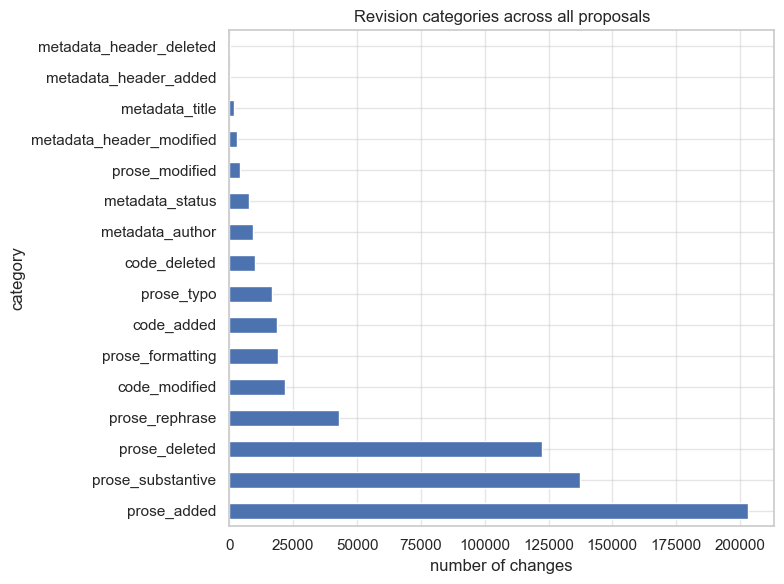

In [5]:
# Combine content + metadata changes into one tidy frame of classified changes.
all_changes = pd.concat([
    content[["project", "category", "op", "block_kind"]],
    meta[["project", "category", "op"]].assign(block_kind="metadata"),
], ignore_index=True)

cat_counts = all_changes["category"].value_counts()
print(cat_counts)

ax = cat_counts.plot.barh(figsize=(8, 6))
ax.set_title("Revision categories across all proposals")
ax.set_xlabel("number of changes")
plt.tight_layout()
plt.savefig(PLOTS / "rq-3.1-categories.svg")
plt.show()

Overall % by part:
 part
prose       88.3
code         8.2
metadata     3.5
Name: proportion, dtype: float64 



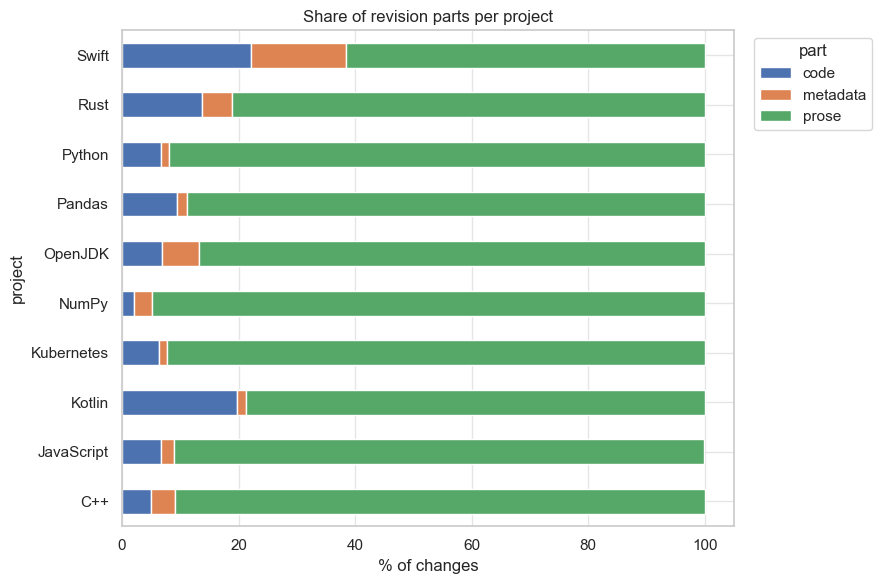

part,code,metadata,prose
project,,,
C++,5.0,4.1,90.9
JavaScript,6.7,2.3,90.9
Kotlin,19.8,1.5,78.7
Kubernetes,6.4,1.3,92.3
NumPy,2.1,3.0,94.9
OpenJDK,6.9,6.4,86.7
Pandas,9.5,1.7,88.8
Python,6.7,1.3,92.0
Rust,13.8,5.1,81.1


In [6]:
# Part-level share (code / prose / metadata) overall and per project.
# Fold inline metadata_header into the structured "metadata" part.
def part(row):
    return "metadata" if "metadata" in row["block_kind"] else row["block_kind"]


all_changes["part"] = all_changes.apply(part, axis=1)
overall = all_changes["part"].value_counts(normalize=True).mul(100).round(1)
print("Overall % by part:\n", overall, "\n")

per_proj = (all_changes.groupby("project")["part"].value_counts(normalize=True)
            .mul(100).unstack().fillna(0).round(1))
ax = per_proj.plot.barh(stacked=True, figsize=(9, 6))
ax.set_title("Share of revision parts per project")
ax.set_xlabel("% of changes")
ax.legend(title="part", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(PLOTS / "rq-3.1-parts-per-project.svg")
plt.show()
per_proj

prose_subtype
substantive    137455
rephrase        42770
formatting      18848
typo            16602
Name: count, dtype: int64


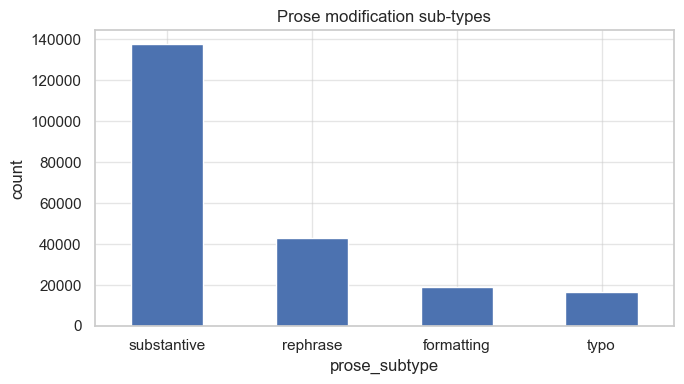

In [7]:
# Prose modification sub-types (typo / formatting / rephrase / substantive).
prose_mods = content[(content["block_kind"] == "prose") &
                     (content["op"] == "modified")]
sub = prose_mods["prose_subtype"].value_counts()
print(sub)
ax = sub.plot.bar(figsize=(7, 4), rot=0)
ax.set_title("Prose modification sub-types")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(PLOTS / "rq-3.1-prose-subtypes.svg")
plt.show()

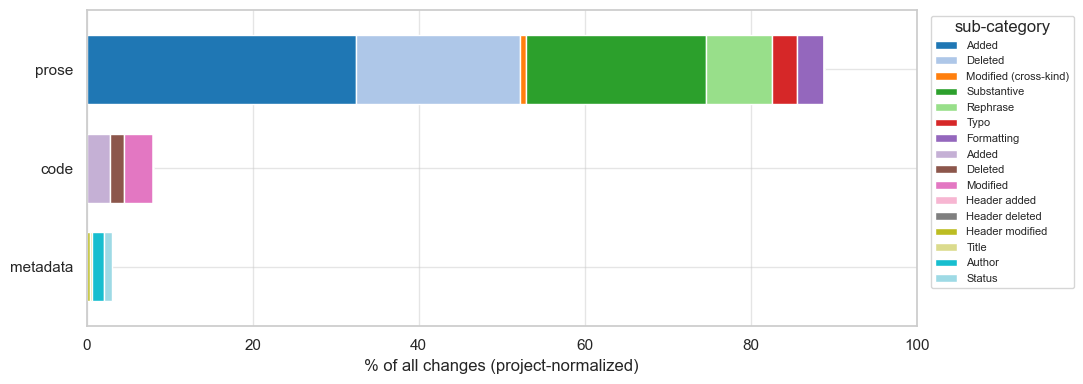

major-part totals (%): {'metadata': 3.1, 'code': 8.0, 'prose': 88.9}


category,prose_added,prose_deleted,prose_modified,prose_substantive,prose_rephrase,prose_typo,prose_formatting,code_added,code_deleted,code_modified,metadata_header_added,metadata_header_deleted,metadata_header_modified,metadata_title,metadata_author,metadata_status
major,,,,,,,,,,,,,,,,
metadata,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.4,0.26,1.37,1.06
code,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.78,1.73,3.51,0.00,0.00,0.0,0.00,0.00,0.00
prose,32.47,19.78,0.71,21.64,7.91,3.02,3.34,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00


In [8]:
# Sub-category breakdown of revisions as a single 100% composition: the three
# major parts (prose / code / metadata) sum to 100% together, each bar's length
# being that part's share of all changes, segmented by sub-category. To keep large
# projects from dominating, per-category counts are first divided by each project's
# proposal count and averaged across projects (equal project weight) before the
# percentages are taken.
allc = pd.concat([content[["project_id", "category"]],
                  meta[["project_id", "category"]]], ignore_index=True)

n_props = pairs.groupby("project_id")["proposal_id"].nunique()
grid = pd.MultiIndex.from_product([n_props.index, sorted(allc["category"].unique())],
                                  names=["project_id", "category"])
counts = allc.groupby(["project_id", "category"]).size().reindex(grid, fill_value=0)
per_proposal = counts.div(n_props, level="project_id")  # rate within each project
mean_rate = per_proposal.groupby("category").mean()  # equal-weight mean across projects

# stable sub-category order within each major part
order = ["prose_added", "prose_deleted", "prose_modified", "prose_substantive",
         "prose_rephrase", "prose_typo", "prose_formatting",
         "code_added", "code_deleted", "code_modified",
         "metadata_header_added", "metadata_header_deleted", "metadata_header_modified",
         "metadata_title", "metadata_author", "metadata_status"]
mr = mean_rate.reset_index(name="rate")
mr["major"] = mr["category"].str.split("_").str[0]
pivot = (mr.pivot_table(index="major", columns="category", values="rate", fill_value=0)
         .reindex(columns=[c for c in order if c in set(mr["category"])]))
# percentage of ALL changes, so the three major bars sum to 100% together
pct = pivot.div(pivot.values.sum()).mul(100).reindex(["metadata", "code", "prose"])

LABELS = {
    "prose_added": "Added",
    "prose_deleted": "Deleted",
    "prose_modified": "Modified (cross-kind)",
    "prose_substantive": "Substantive",
    "prose_rephrase": "Rephrase",
    "prose_typo": "Typo",
    "prose_formatting": "Formatting",
    "code_added": "Added",
    "code_deleted": "Deleted",
    "code_modified": "Modified",
    "metadata_header_added": "Header added",
    "metadata_header_deleted": "Header deleted",
    "metadata_header_modified": "Header modified",
    "metadata_title": "Title",
    "metadata_author": "Author",
    "metadata_status": "Status",
}

ax = pct.rename(columns=LABELS).plot.barh(stacked=True, figsize=(11, 4), colormap="tab20", width=0.7)
ax.set_xlim(0, 100)
ax.set_xlabel("% of all changes (project-normalized)")
ax.set_ylabel("")
# ax.set_title("Revision sub-categories by part (share of all changes)")
ax.legend(title="sub-category", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS / "rq-3.1-subcategories-normalized.svg")
plt.show()
print("major-part totals (%):", pct.sum(axis=1).round(1).to_dict())
pct.round(2)

## Extra — How frequently are proposals changed?

count    12642.000000
mean         7.151558
std         15.162114
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        308.000000
Name: n_revisions, dtype: float64


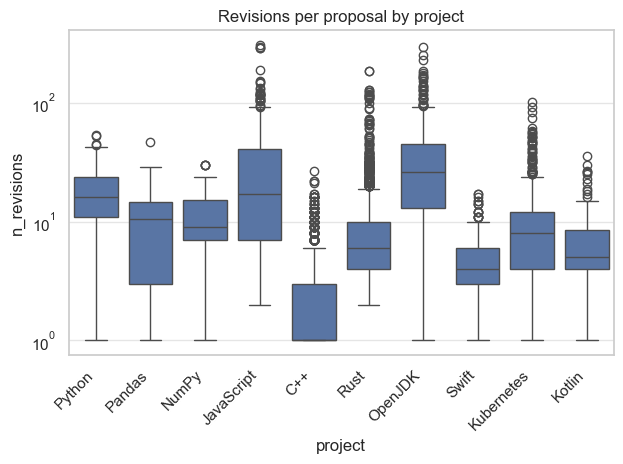

In [9]:
# Distribution of revisions per proposal, overall and per project.
print(pairs["n_revisions"].describe())
ax = sns.boxplot(data=pairs, x="project", y="n_revisions")
ax.set_yscale("log")
ax.set_title("Revisions per proposal by project")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PLOTS / "extra-revisions-per-project.svg")
plt.show()

Medians by status group:
               n_revisions  lifespan_days  revisions_per_month
status_group                                                 
in_progress           1.0       0.000000            30.440000
terminal              5.0     310.016331             0.722423 

status_group  latest_status
in_progress   draft            1122
              review            623
              unknown            13
terminal      accepted         3183
              rejected         2473
              superseded         59
              withdrawn         118
dtype: int64


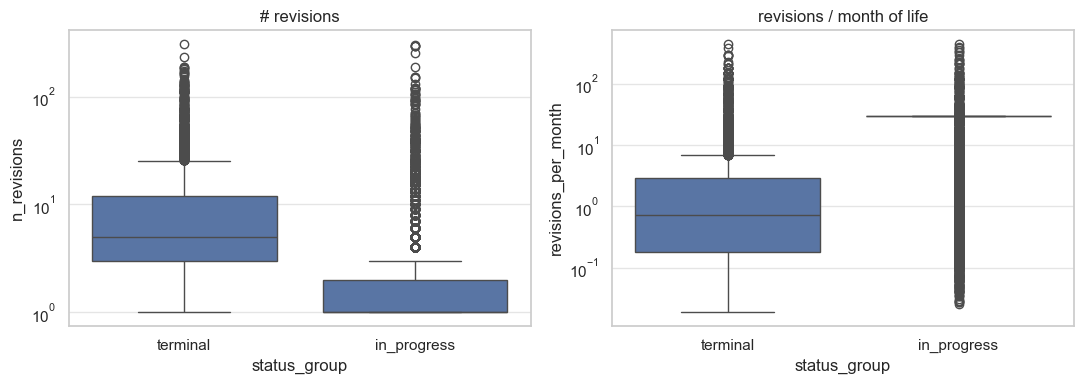

In [10]:
# In-progress (draft/review) vs terminal (accepted/rejected/withdrawn/superseded).
summary = (pairs.groupby("status_group")[["n_revisions", "lifespan_days",
                                          "revisions_per_month"]].median())
print("Medians by status group:\n", summary, "\n")
print(pairs.groupby(["status_group", "latest_status"]).size())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=pairs, x="status_group", y="n_revisions", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("# revisions")
sns.boxplot(data=pairs, x="status_group", y="revisions_per_month", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("revisions / month of life")
plt.tight_layout()
plt.savefig(PLOTS / "extra-status-group.svg")
plt.show()

In [11]:
# Reconciliation: every content change is accounted for by exactly one category.
assert content["category"].notna().all()
assert len(content) == content["category"].value_counts().sum()
print("content changes:", len(content), "= sum of category counts (ok)")

content changes: 598742 = sum of category counts (ok)


## Step 3 — Refinement loop

Run the cell below to print random classified changes and eyeball whether the
assigned category is right. When you spot systematic mistakes, tune the
thresholds / rules in `revision_analysis/classify.py` and re-run with
`load_or_run(force=True)`.

In [32]:
from revision_analysis.diff import diff_revisions
from revision_analysis.segment import format_for_project


# Inspect a specific proposal: re-diff its consecutive revisions and print the
# old/new text next to the assigned category. This is the manual-refinement view
# (full text is not cached in parquet, so we recompute on demand). Revisions are
# fetched in the corrected chronological order (db.ordered_revisions).
def inspect(project_id, proposal_id, max_changes=20):
    fmt = format_for_project(project_id)  # fixed format for single-format projects
    with db.connect() as con:
        revs = db.ordered_revisions(con, project_id, proposal_id)
    shown = 0
    for a, b in zip(revs, revs[1:]):
        print("=" * 80)
        for ch in diff_revisions(a.content, b.content, fmt):
            print("-" * 80)
            print(f"{ch.category}  (op={ch.op}, kind={ch.block_kind},"
                  f" subtype={ch.prose_subtype})")
            if ch.old:
                print("  OLD:", ch.old.replace("\n", " "))
            if ch.new:
                print("  NEW:", ch.new.replace("\n", " "))
            shown += 1
            if shown >= max_changes:
                return


# Pick a random multi-revision proposal to inspect.
cand = content.drop_duplicates(["project_id", "proposal_id"]).sample(1).iloc[0]
print(f"Inspecting [{cand['project']}] proposal {cand['proposal_id']}\n")
inspect(int(cand["project_id"]), cand["proposal_id"])

Inspecting [Rust] proposal 1909

--------------------------------------------------------------------------------
prose_substantive  (op=modified, kind=prose, subtype=substantive)
  OLD: 1) Passing unsized values, such as trait objects, to functions by value is often desired. Currently, this must be done through a `Box<T>` with an unnecessary allocation.
  NEW: 1. Passing unsized values, such as trait objects, to functions by value is often desired. Currently, this must be done through a `Box<T>` with an unnecessary allocation.
--------------------------------------------------------------------------------
prose_substantive  (op=modified, kind=prose, subtype=substantive)
  OLD: 2) Allocating a runtime-sized variable on the stack is important for good performance in some use-cases - see RFC #1808, which this is intended to supersede.
  NEW: 2. Allocating a runtime-sized variable on the stack is important for good performance in some use-cases - see RFC #1808, which this is intended to 